## Epoch to Epoch Plotting (in training evalution)

In [1]:
import sys
import json
from pathlib import Path

sys.path.insert(0, str(Path('../').resolve()))
from src.training_viz import plot_training_curves

# Auto-resolve: pick the most recently modified run folder (same pattern as 04_model_evaluation).
# Override RUN_TAG manually to visualize a specific run.
runs_root = Path('../models/runs')
RUN_TAG = globals().get('RUN_TAG', None)

if RUN_TAG is None:
    assert runs_root.exists(), f"Missing runs directory: {runs_root}"
    run_dirs = sorted(
        [p for p in runs_root.iterdir() if p.is_dir()],
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )
    assert run_dirs, f"No run folders found in {runs_root}"
    run_dir = run_dirs[0]
    RUN_TAG = run_dir.name
else:
    run_dir = runs_root / RUN_TAG

print('RUN_TAG:', RUN_TAG)
print('run_dir:', run_dir)

RUN_TAG: 20260511_200157
run_dir: ../models/runs/20260511_200157


Saved training_curves.png to ../models/runs/20260511_200157


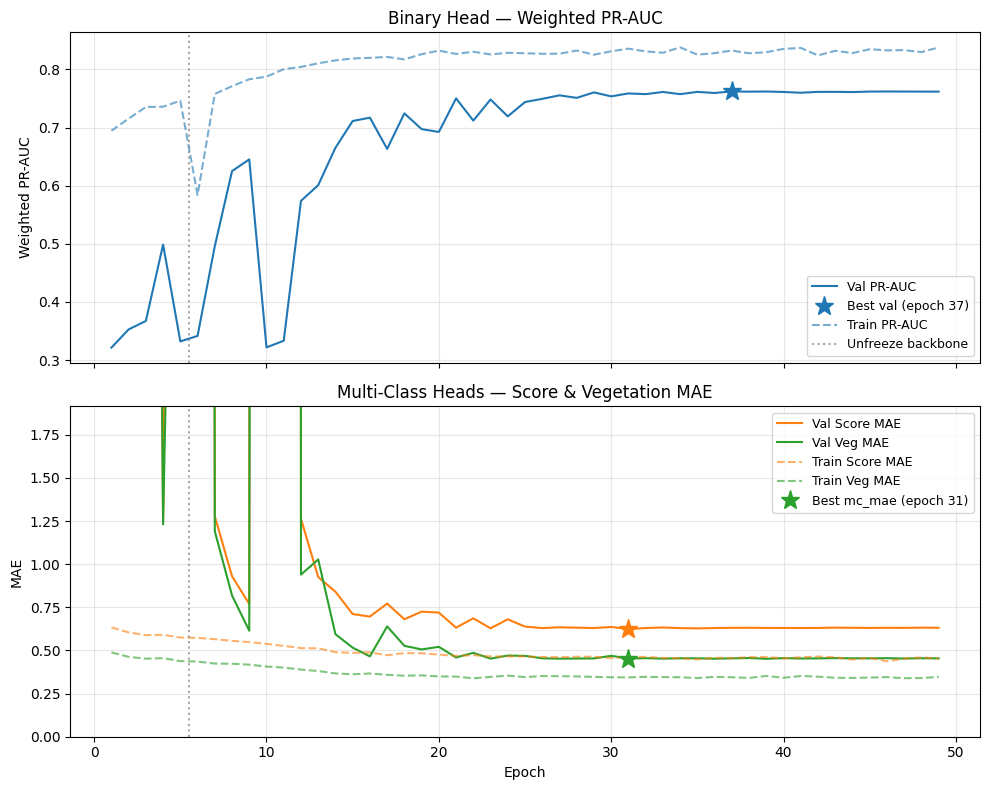

In [2]:
with open(run_dir / f'training_history_{RUN_TAG}.json') as f:
    history = json.load(f)
with open(run_dir / f'model_config_{RUN_TAG}.json') as f:
    config = json.load(f)

plot_training_curves(history, warmup_epochs=config['warmup_epochs'], save_dir=run_dir)

---

## Score & Veg Distribution Plot

Counts of **`score_class`** and **`veg_class`** (ordinal **1–5**) on **train / val / test** from `data/processed/splits/`. Use this to see **imbalance**, **sparse bins**, and **split shift** — not as a substitute for **val/test MAE** (interpret MAE with baselines and per-class error separately).

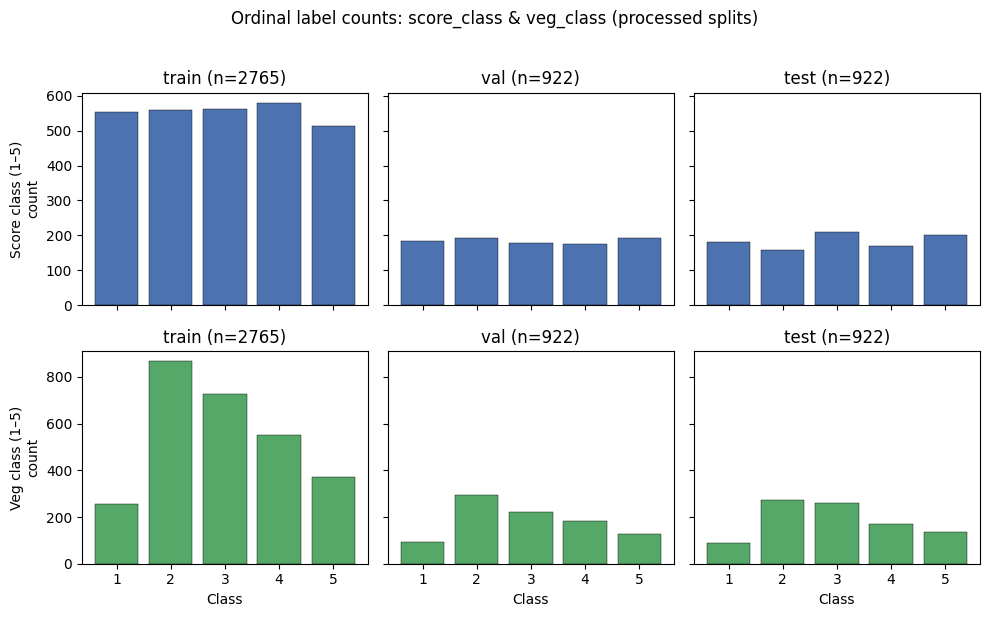

Saved: /Users/starsrain/2025_codeProject/GreenSpace_CNN/presentation_visuals_only/eval_visuals/score_veg_split_distributions.png


In [3]:
# Train / val / test score_class & veg_class counts (ordinal labels 1–5 from split manifests).
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

splits_dir = Path('../data/processed/splits').resolve()
train_df = pd.read_csv(splits_dir / 'train.csv')
val_df = pd.read_csv(splits_dir / 'val.csv')
test_df = pd.read_csv(splits_dir / 'test.csv')

for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    for col in ('score_class', 'veg_class'):
        assert col in df.columns, f"Missing {col} in {name}.csv (run 02_data_preprocessing)"

classes = np.arange(1, 6)


def counts_1to5(series: pd.Series) -> np.ndarray:
    s = series.fillna(0).astype(int).clip(1, 5)
    vc = s.value_counts().reindex(classes, fill_value=0)
    return vc.values.astype(float)


rows = [
    ('score_class', 'Score class (1–5)'),
    ('veg_class', 'Veg class (1–5)'),
]
cols = [
    ('train', train_df, len(train_df)),
    ('val', val_df, len(val_df)),
    ('test', test_df, len(test_df)),
]

fig, axes = plt.subplots(2, 3, figsize=(10, 6), sharex=True, sharey='row')
for r, (col, row_title) in enumerate(rows):
    for c, (split_name, df, n) in enumerate(cols):
        ax = axes[r, c]
        y = counts_1to5(df[col])
        ax.bar(classes, y, color='#4C72B0' if r == 0 else '#55A868', edgecolor='black', linewidth=0.3)
        ax.set_xticks(classes)
        ax.set_title(f'{split_name} (n={n})')
        if c == 0:
            ax.set_ylabel(f'{row_title}\ncount')
        if r == 1:
            ax.set_xlabel('Class')

fig.suptitle(
    'Ordinal label counts: score_class & veg_class (processed splits)',
    fontsize=12,
    y=1.02,
)
fig.tight_layout()

out_dir = Path('../presentation_visuals_only/eval_visuals').resolve()
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'score_veg_split_distributions.png'
fig.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out_path)
